# Prospective Memory Analysis (From Pre-Sampled Trajectories)

This notebook reproduces the prospective-memory geometric analysis pipeline, but uses already-saved teacher trajectories from:

`results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_6/ablated_teacher_trajectories`

It avoids model sampling and instead loads `ablated_teacher_trajectories_sweep_step_*.pt` files, extracts `postprep_state` at each `prep_idx`, and runs the same cue/color PCA and plane analyses.

In [1]:
import os
import sys
import json
import colorsys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)

REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

TRAJ_DIR = REPO_ROOT / 'results_link_sampler' / 'index_cued_first_diffusion_swap_recovery_9' / 'ablated_teacher_trajectories'
RUN_NAME = TRAJ_DIR.parent.name
RESULTS_DIR = REPO_ROOT / 'ddpm' / 'analysis' / 'new_analysis' / 'results' / f'{RUN_NAME}_sampled_trajectories'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PREP_INDICES = [0, 1, 2, 3]
PREP_IDX = 2
N_BINS = 12

print(f'Working directory: {os.getcwd()}')
print(f'Trajectory directory: {TRAJ_DIR}')
print(f'Results directory: {RESULTS_DIR}')

Working directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis
Trajectory directory: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_swap_recovery_9/ablated_teacher_trajectories
Results directory: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis/results/index_cued_first_diffusion_swap_recovery_9_sampled_trajectories


In [2]:
def list_sweep_files(traj_dir: Path):
    files = sorted(traj_dir.glob('ablated_teacher_trajectories_sweep_step_*.pt'))
    if not files:
        raise FileNotFoundError(f'No sweep files found in {traj_dir}')
    return files


def load_states_and_metadata_from_sweeps(traj_dir: Path, prep_indices=(0, 1, 2, 3), reduce_samples='mean'):
    sweep_files = list_sweep_files(traj_dir)

    states_by_prep = {idx: [] for idx in prep_indices}
    metadata_rows = []

    for fi, path in enumerate(sweep_files):
        data = torch.load(path, map_location='cpu', weights_only=False)

        trials = data.get('sweep_batch_trials', None)
        prep_dicts = data.get('ablated_teacher_prep_dicts', None)

        if trials is None or prep_dicts is None:
            continue

        for prep_idx in prep_indices:
            postprep = prep_dicts[prep_idx]['postprep_state']  # [batch, samples, dim]
            if reduce_samples == 'mean':
                postprep_reduced = postprep.mean(dim=1)
            elif reduce_samples == 'first':
                postprep_reduced = postprep[:, 0, :]
            else:
                raise ValueError(f'Unknown reduce_samples={reduce_samples}')

            states_by_prep[prep_idx].append(postprep_reduced.numpy())

        for tr in trials:
            metadata_rows.append([int(tr['cue']), float(tr['color1_angle']), float(tr['color2_angle'])])

        if (fi + 1) % 25 == 0:
            print(f'Loaded {fi + 1}/{len(sweep_files)} files...')

    if len(metadata_rows) == 0:
        raise RuntimeError('No valid sweep rows loaded. Check trajectory files.')

    metadata = np.asarray(metadata_rows, dtype=np.float32)
    for prep_idx in prep_indices:
        states_by_prep[prep_idx] = np.concatenate(states_by_prep[prep_idx], axis=0)

    return states_by_prep, metadata, sweep_files


def bin_angle(angle, bin_size):
    return int(angle // bin_size) % int(360 // bin_size)


def bin_and_average_by_cued_color(states, metadata, n_bins=12):
    bin_size = 360.0 / n_bins

    binned_data = {
        1: {b: [] for b in range(n_bins)},
        2: {b: [] for b in range(n_bins)},
    }

    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        cued_angle = c1 if cue == 1 else c2
        b = bin_angle(cued_angle, bin_size)
        binned_data[cue][b].append(states[i])

    averaged = {
        1: np.zeros((n_bins, states.shape[1]), dtype=np.float32),
        2: np.zeros((n_bins, states.shape[1]), dtype=np.float32),
    }

    for cue in [1, 2]:
        for b in range(n_bins):
            if len(binned_data[cue][b]) > 0:
                averaged[cue][b] = np.mean(binned_data[cue][b], axis=0)
            else:
                averaged[cue][b] = np.nan

    return averaged, binned_data


def bin_by_target_and_distractor(states, metadata, n_bins=12):
    bin_size = 360.0 / n_bins

    binned = {1: {}, 2: {}}

    for i, (cue, c1, c2) in enumerate(metadata):
        cue = int(cue)
        if cue == 1:
            target_angle = c1
            distractor_angle = c2
        else:
            target_angle = c2
            distractor_angle = c1

        tb = bin_angle(target_angle, bin_size)
        db = bin_angle(distractor_angle, bin_size)
        key = (tb, db)

        if key not in binned[cue]:
            binned[cue][key] = []
        binned[cue][key].append(states[i])

    averaged = {1: {}, 2: {}}
    counts = {1: {}, 2: {}}
    for cue in [1, 2]:
        for key, vals in binned[cue].items():
            averaged[cue][key] = np.mean(vals, axis=0)
            counts[cue][key] = len(vals)

    return averaged, counts


def fit_plane_to_data(data):
    center = np.mean(data, axis=0)
    centered = data - center
    pca = PCA(n_components=3)
    pca.fit(centered)

    normal = pca.components_[2]
    normal = normal / np.linalg.norm(normal)
    variance = pca.explained_variance_ratio_
    planarity = variance[:2].sum()
    return normal, center, planarity, variance


def angle_between_planes_degrees(normal1, normal2):
    cos_angle = np.abs(np.dot(normal1, normal2))
    cos_angle = min(1.0, max(0.0, cos_angle))
    return np.degrees(np.arccos(cos_angle))

In [3]:
states_by_prep, metadata, sweep_files = load_states_and_metadata_from_sweeps(
    TRAJ_DIR,
    prep_indices=tuple(PREP_INDICES),
    reduce_samples='mean',
)

print(f'Loaded {len(sweep_files)} sweep files')
print(f'Total trials: {metadata.shape[0]}')
for prep_idx in PREP_INDICES:
    print(f'prep_idx={prep_idx} states shape: {states_by_prep[prep_idx].shape}')

neural_states = states_by_prep[PREP_IDX]
print(f'\nUsing PREP_IDX={PREP_IDX} for primary analysis')
print(f'Primary neural state shape: {neural_states.shape}')

FileNotFoundError: No sweep files found in /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_swap_recovery_9/ablated_teacher_trajectories

In [4]:
# 8x3 behavioural trajectory grid from sampled teacher trajectories
N_VIS_TRIALS = 24
N_COLS = 3
N_ROWS = int(np.ceil(N_VIS_TRIALS / N_COLS))
N_SAMPLE_PATHS_PER_TRIAL = 48

sweep_files_beh = list_sweep_files(TRAJ_DIR)
target_file_beh = sweep_files_beh[-1]
print(f'Using behavioural trajectory source: {target_file_beh.name}')

data_beh = torch.load(target_file_beh, map_location='cpu', weights_only=False)
if 'ablated_teacher_trajectories' not in data_beh:
    raise RuntimeError('Expected ablated_teacher_trajectories in sampled sweep file.')

trial_rows_beh = data_beh.get('sweep_batch_trials', None)
if trial_rows_beh is None:
    trial_rows_beh = data_beh.get('trial_info', None)
if trial_rows_beh is None:
    raise RuntimeError('Expected sweep_batch_trials or trial_info in sampled sweep file.')

state_path_beh = TRAJ_DIR.parent / 'state.mdl'
if not state_path_beh.exists():
    raise FileNotFoundError(f'Model checkpoint not found: {state_path_beh}')

state_dict_beh = torch.load(state_path_beh, map_location='cpu', weights_only=False)
if 'auxiliary_embedding_matrix' not in state_dict_beh:
    raise RuntimeError('auxiliary_embedding_matrix not found in state.mdl')

aux_beh = state_dict_beh['auxiliary_embedding_matrix'].detach().cpu().numpy() if torch.is_tensor(state_dict_beh['auxiliary_embedding_matrix']) else np.asarray(state_dict_beh['auxiliary_embedding_matrix'])

embedded_traj_beh = data_beh['ablated_teacher_trajectories'].detach().cpu().numpy() if torch.is_tensor(data_beh['ablated_teacher_trajectories']) else np.asarray(data_beh['ablated_teacher_trajectories'])
# [batch, samples, T, 16] -> [batch, samples, T, 2]
beh_traj = np.einsum('bstk,dk->bstd', embedded_traj_beh, aux_beh)

# Project each point to unit circle to visualise pure angular behaviour
beh_norm = np.linalg.norm(beh_traj, axis=-1, keepdims=True)
beh_traj_unit = beh_traj / (beh_norm + 1e-9)

n_trials_total = beh_traj_unit.shape[0]
vis_trials = min(N_VIS_TRIALS, n_trials_total)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(15, 4.5 * N_ROWS))
axes = np.asarray(axes).reshape(-1)

theta = np.linspace(0, 2 * np.pi, 360)
for t in range(len(axes)):
    ax = axes[t]
    if t >= vis_trials:
        ax.axis('off')
        continue

    tr = trial_rows_beh[t]
    cue = int(tr['cue'])
    c1 = float(tr['color1_angle']) % 360.0
    c2 = float(tr['color2_angle']) % 360.0
    target_angle = c1 if cue == 1 else c2
    distractor_angle = c2 if cue == 1 else c1

    trial_paths = beh_traj_unit[t]  # [samples, T, 2]
    n_samples_trial = trial_paths.shape[0]
    idx = np.linspace(0, n_samples_trial - 1, min(N_SAMPLE_PATHS_PER_TRIAL, n_samples_trial), dtype=int)

    ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.25, linewidth=1.0)

    for s in idx:
        xy = trial_paths[s]
        ax.plot(xy[:, 0], xy[:, 1], color='tab:blue', alpha=0.08, linewidth=0.9)

    mean_xy = trial_paths.mean(axis=0)
    mean_xy = mean_xy / (np.linalg.norm(mean_xy, axis=1, keepdims=True) + 1e-9)
    ax.plot(mean_xy[:, 0], mean_xy[:, 1], color='black', linewidth=2.0, alpha=0.9)

    tx, ty = np.cos(np.deg2rad(target_angle)), np.sin(np.deg2rad(target_angle))
    ux, uy = np.cos(np.deg2rad(distractor_angle)), np.sin(np.deg2rad(distractor_angle))
    ax.scatter([tx], [ty], marker='*', s=130, color='tab:green', edgecolors='k', linewidths=0.8, zorder=5)
    ax.scatter([ux], [uy], marker='x', s=90, color='tab:orange', linewidths=2.0, zorder=5)

    ax.set_aspect('equal')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        f'Trial {t} | cue={cue} | target={target_angle:.1f} deg | uncued={distractor_angle:.1f} deg',
        fontsize=9,
        fontweight='bold'
    )

fig.suptitle('Behavioural Trajectories From Sampled Teacher States (Unit Circle)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
out_path_beh = RESULTS_DIR / 'behaviour_trajectory_grid_sampled.png'
plt.savefig(out_path_beh, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', out_path_beh)
print(f'Visualised {vis_trials} trials from {target_file_beh.name}')
print(f'Decoded trajectory shape: {beh_traj_unit.shape}')

FileNotFoundError: No sweep files found in /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_swap_recovery_9/ablated_teacher_trajectories

## Behaviour Trajectory Visualisation From Loaded Samples

This section visualises decoded behavioural trajectories directly from the loaded sampled teacher trajectories (`ablated_teacher_trajectories`).

Each panel shows one trial:
- thin blue lines: individual sampled behavioural trajectories
- thick black line: trial-mean trajectory
- green star: cued/target angle
- orange x: uncued/distractor angle

In [5]:
cue1_mask = metadata[:, 0] == 1
cue2_mask = metadata[:, 0] == 2

cue1_states = neural_states[cue1_mask]
cue2_states = neural_states[cue2_mask]

cue1_mean = cue1_states.mean(axis=0)
cue2_mean = cue2_states.mean(axis=0)

print(f'Cue 1 trials: {len(cue1_states)}')
print(f'Cue 2 trials: {len(cue2_states)}')
print('Difference between cue means:')
print(f'  Max abs diff: {np.abs(cue1_mean - cue2_mean).max():.6f}')
print(f'  Mean abs diff: {np.abs(cue1_mean - cue2_mean).mean():.6f}')
print(f'  L2 distance: {np.linalg.norm(cue1_mean - cue2_mean):.6f}')

NameError: name 'metadata' is not defined

In [6]:
averaged_states, binned_trials = bin_and_average_by_cued_color(neural_states, metadata, n_bins=N_BINS)

print(f'Binned into {N_BINS} bins (30 deg) by cued color')
for cue in [1, 2]:
    counts = [len(binned_trials[cue][b]) for b in range(N_BINS)]
    print(f'  Cue {cue} counts: {counts}')

all_binned_states = np.vstack([averaged_states[1], averaged_states[2]])
valid_mask = ~np.isnan(all_binned_states).any(axis=1)
all_binned_states_clean = all_binned_states[valid_mask]

pca = PCA(n_components=min(3, all_binned_states_clean.shape[0] - 1))
pca_coords = pca.fit_transform(all_binned_states_clean)

cue1_pca = pca_coords[:N_BINS]
cue2_pca = pca_coords[N_BINS:N_BINS * 2]

cue1_center = cue1_pca.mean(axis=0)
cue2_center = cue2_pca.mean(axis=0)
separation = np.linalg.norm(cue1_center - cue2_center)

print('PCA explained variance ratio:', pca.explained_variance_ratio_)
print('Cue separation in PCA space:', separation)

NameError: name 'neural_states' is not defined

NameError: name 'cue1_pca' is not defined

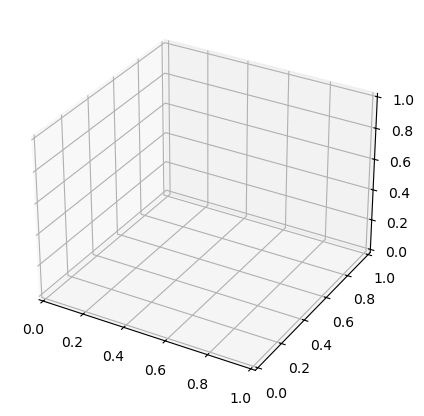

In [7]:
fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(cue1_pca[:, 0], cue1_pca[:, 1], cue1_pca[:, 2], c='red', marker='o', s=90, alpha=0.75, edgecolors='darkred', label='Cue 1')
ax1.scatter(cue2_pca[:, 0], cue2_pca[:, 1], cue2_pca[:, 2], c='blue', marker='^', s=90, alpha=0.75, edgecolors='darkblue', label='Cue 2')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax1.set_title('3D Cue Separation')
ax1.legend()

ax2 = fig.add_subplot(132)
ax2.scatter(cue1_pca[:, 0], cue1_pca[:, 1], c='red', marker='o', s=90, alpha=0.75, edgecolors='darkred', label='Cue 1')
ax2.scatter(cue2_pca[:, 0], cue2_pca[:, 1], c='blue', marker='^', s=90, alpha=0.75, edgecolors='darkblue', label='Cue 2')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax2.set_title('PC1 vs PC2')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')
ax2.legend()

ax3 = fig.add_subplot(133)
ax3.scatter(cue1_pca[:, 1], cue1_pca[:, 2], c='red', marker='o', s=90, alpha=0.75, edgecolors='darkred', label='Cue 1')
ax3.scatter(cue2_pca[:, 1], cue2_pca[:, 2], c='blue', marker='^', s=90, alpha=0.75, edgecolors='darkblue', label='Cue 2')
ax3.set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax3.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax3.set_title('PC2 vs PC3')
ax3.grid(True, alpha=0.3)
ax3.axis('equal')
ax3.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prospective_memory_pca_3d_sampled.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
averaged_2d, bin_counts_2d = bin_by_target_and_distractor(neural_states, metadata, n_bins=N_BINS)

all_2d_states = []
all_2d_meta = []
for cue in [1, 2]:
    for (tb, db), state in averaged_2d[cue].items():
        all_2d_states.append(state)
        all_2d_meta.append((cue, tb, db))

all_2d_states = np.asarray(all_2d_states)
all_2d_meta = np.asarray(all_2d_meta)

pca_2d = PCA(n_components=3)
pca_coords_2d = pca_2d.fit_transform(all_2d_states)

cue1_mask_2d = all_2d_meta[:, 0] == 1
cue2_mask_2d = all_2d_meta[:, 0] == 2

cue1_pca_2d = pca_coords_2d[cue1_mask_2d]
cue2_pca_2d = pca_coords_2d[cue2_mask_2d]
cue1_meta_2d = all_2d_meta[cue1_mask_2d]
cue2_meta_2d = all_2d_meta[cue2_mask_2d]

print(f'Cue 1 non-empty 2D bins: {len(cue1_pca_2d)}')
print(f'Cue 2 non-empty 2D bins: {len(cue2_pca_2d)}')
print('2D-binned PCA explained variance ratio:', pca_2d.explained_variance_ratio_)

NameError: name 'neural_states' is not defined

In [9]:
target_only = {}
distractor_only = {}

for tb in range(N_BINS):
    vals = []
    for cue in [1, 2]:
        for (tbin, dbin), state in averaged_2d[cue].items():
            if tbin == tb:
                vals.append(state)
    if vals:
        target_only[tb] = np.mean(vals, axis=0)

for db in range(N_BINS):
    vals = []
    for cue in [1, 2]:
        for (tbin, dbin), state in averaged_2d[cue].items():
            if dbin == db:
                vals.append(state)
    if vals:
        distractor_only[db] = np.mean(vals, axis=0)

combined_states = []
combined_meta = []
for b, st in sorted(target_only.items()):
    combined_states.append(st)
    combined_meta.append((0, b))
for b, st in sorted(distractor_only.items()):
    combined_states.append(st)
    combined_meta.append((1, b))

combined_states = np.asarray(combined_states)
combined_meta = np.asarray(combined_meta)

pca_combined = PCA(n_components=3)
combined_pca = pca_combined.fit_transform(combined_states)

target_pca = combined_pca[combined_meta[:, 0] == 0]
distractor_pca = combined_pca[combined_meta[:, 0] == 1]

target_normal, target_center, target_planarity, _ = fit_plane_to_data(target_pca)
distractor_normal, distractor_center, distractor_planarity, _ = fit_plane_to_data(distractor_pca)
plane_angle = angle_between_planes_degrees(target_normal, distractor_normal)
plane_sep = np.linalg.norm(target_center - distractor_center)

print('Combined target/distractor PCA explained variance:', pca_combined.explained_variance_ratio_)
print(f'Angle between target and distractor planes: {plane_angle:.2f} deg')
print(f'Center separation: {plane_sep:.4f}')
print(f'Target planarity: {target_planarity:.2%}')
print(f'Distractor planarity: {distractor_planarity:.2%}')

NameError: name 'averaged_2d' is not defined

In [10]:
# Visualisation: target vs distractor encoding (combined), matching original layout
N_COLOR_BINS = 12

target_bins_combined = combined_meta[combined_meta[:, 0] == 0, 1].astype(int)
distractor_bins_combined = combined_meta[combined_meta[:, 0] == 1, 1].astype(int)

def angle_to_colour(bin_idx, n_bins=12):
    hue = bin_idx / n_bins
    return colorsys.hsv_to_rgb(hue, 0.9, 0.9)

fig = plt.figure(figsize=(18, 5))

ax = fig.add_subplot(131, projection='3d')
for i in range(len(target_pca)):
    colour = angle_to_colour(target_bins_combined[i], N_COLOR_BINS)
    ax.scatter(target_pca[i, 0], target_pca[i, 1], target_pca[i, 2], c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)
for i in range(len(distractor_pca)):
    colour = angle_to_colour(distractor_bins_combined[i], N_COLOR_BINS)
    ax.scatter(distractor_pca[i, 0], distractor_pca[i, 1], distractor_pca[i, 2], c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)
ax.set_xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_combined.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('3D View\nO Target, ^ Distractor', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

ax2 = fig.add_subplot(132)
for i in range(len(target_pca)):
    colour = angle_to_colour(target_bins_combined[i], N_COLOR_BINS)
    ax2.scatter(target_pca[i, 0], target_pca[i, 1], c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)
for i in range(len(distractor_pca)):
    colour = angle_to_colour(distractor_bins_combined[i], N_COLOR_BINS)
    ax2.scatter(distractor_pca[i, 0], distractor_pca[i, 1], c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)
ax2.set_xlabel(f'PC1 ({pca_combined.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
for i in range(len(target_pca)):
    colour = angle_to_colour(target_bins_combined[i], N_COLOR_BINS)
    ax3.scatter(target_pca[i, 1], target_pca[i, 2], c=[colour], marker='o', s=150, alpha=0.8, edgecolors='k', linewidth=2)
for i in range(len(distractor_pca)):
    colour = angle_to_colour(distractor_bins_combined[i], N_COLOR_BINS)
    ax3.scatter(distractor_pca[i, 1], distractor_pca[i, 2], c=[colour], marker='^', s=120, alpha=0.8, edgecolors='grey', linewidth=1.5)
ax3.set_xlabel(f'PC2 ({pca_combined.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'PC3 ({pca_combined.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax3.set_title('PC2 vs PC3', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png')

NameError: name 'combined_meta' is not defined

In [11]:
# Visualize fitted target/distractor planes (2x2), matching original figure style
def create_plane_mesh(normal, center, size=150):
    if abs(normal[0]) < 0.9:
        v1 = np.array([1, 0, 0])
    else:
        v1 = np.array([0, 1, 0])
    v1 = v1 - np.dot(v1, normal) * normal
    v1 = v1 / np.linalg.norm(v1)
    v2 = np.cross(normal, v1)
    v2 = v2 / np.linalg.norm(v2)
    u = np.linspace(-size, size, 10)
    v = np.linspace(-size, size, 10)
    U, V = np.meshgrid(u, v)
    X = center[0] + U * v1[0] + V * v2[0]
    Y = center[1] + U * v1[1] + V * v2[1]
    Z = center[2] + U * v1[2] + V * v2[2]
    return X, Y, Z

target_X, target_Y, target_Z = create_plane_mesh(target_normal, target_center)
distractor_X, distractor_Y, distractor_Z = create_plane_mesh(distractor_normal, distractor_center)

fig = plt.figure(figsize=(16, 12))

ax = fig.add_subplot(2, 2, 1, projection='3d')
ax.plot_surface(target_X, target_Y, target_Z, alpha=0.15, color='red')
ax.plot_surface(distractor_X, distractor_Y, distractor_Z, alpha=0.15, color='blue')
ax.scatter(target_pca[:, 0], target_pca[:, 1], target_pca[:, 2], c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, alpha=0.8, label='Target')
ax.scatter(distractor_pca[:, 0], distractor_pca[:, 1], distractor_pca[:, 2], c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Distractor')
arrow_scale = 50
ax.quiver(0, 0, 0, target_normal[0] * arrow_scale, target_normal[1] * arrow_scale, target_normal[2] * arrow_scale, color='darkred', arrow_length_ratio=0.2, linewidth=3, label='Target normal')
ax.quiver(0, 0, 0, distractor_normal[0] * arrow_scale, distractor_normal[1] * arrow_scale, distractor_normal[2] * arrow_scale, color='darkblue', arrow_length_ratio=0.2, linewidth=3, label='Distractor normal')
ax.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax.set_zlabel('PC3', fontsize=12, fontweight='bold')
ax.set_title(f'3D View with Fitted Planes\nAngle = {plane_angle:.2f} deg', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(target_pca[:, 0], target_pca[:, 1], c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, alpha=0.8, label='Target')
ax2.scatter(distractor_pca[:, 0], distractor_pca[:, 1], c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Distractor')
target_normal_proj = target_normal[:2] / np.linalg.norm(target_normal[:2])
distractor_normal_proj = distractor_normal[:2] / np.linalg.norm(distractor_normal[:2])
target_line_dir = np.array([-target_normal_proj[1], target_normal_proj[0]])
distractor_line_dir = np.array([-distractor_normal_proj[1], distractor_normal_proj[0]])
line_length = 120
for sign in [-1, 1]:
    ax2.plot([0, sign * line_length * target_line_dir[0]], [0, sign * line_length * target_line_dir[1]], 'r--', linewidth=2, alpha=0.5)
    ax2.plot([0, sign * line_length * distractor_line_dir[0]], [0, sign * line_length * distractor_line_dir[1]], 'b--', linewidth=2, alpha=0.5)
ax2.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax2.set_ylabel('PC2', fontsize=12, fontweight='bold')
ax2.set_title('PC1-PC2 View', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(2, 2, 3)
ax3.scatter(target_pca[:, 0], target_pca[:, 2], c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, alpha=0.8, label='Target')
ax3.scatter(distractor_pca[:, 0], distractor_pca[:, 2], c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Distractor')
ax3.set_xlabel('PC1', fontsize=12, fontweight='bold')
ax3.set_ylabel('PC3', fontsize=12, fontweight='bold')
ax3.set_title('PC1-PC3 View', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

ax4 = fig.add_subplot(2, 2, 4)
ax4.scatter(target_pca[:, 1], target_pca[:, 2], c='red', marker='o', s=100, edgecolors='darkred', linewidths=2, alpha=0.8, label='Target')
ax4.scatter(distractor_pca[:, 1], distractor_pca[:, 2], c='blue', marker='^', s=100, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Distractor')
ax4.set_xlabel('PC2', fontsize=12, fontweight='bold')
ax4.set_ylabel('PC3', fontsize=12, fontweight='bold')
ax4.set_title('PC2-PC3 View', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_aspect('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plane_fitting_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / 'plane_fitting_visualization.png')

NameError: name 'target_normal' is not defined

In [12]:
all_prep_results = {}

for prep_idx in PREP_INDICES:
    states = states_by_prep[prep_idx]
    averaged, _ = bin_and_average_by_cued_color(states, metadata, n_bins=N_BINS)
    stacked = np.vstack([averaged[1], averaged[2]])
    valid = ~np.isnan(stacked).any(axis=1)
    stacked = stacked[valid]

    pca_prep = PCA(n_components=3)
    coords = pca_prep.fit_transform(stacked)

    cue1_pca = coords[:N_BINS]
    cue2_pca = coords[N_BINS:N_BINS * 2]

    cue1_normal, cue1_center, cue1_planarity, _ = fit_plane_to_data(cue1_pca)
    cue2_normal, cue2_center, cue2_planarity, _ = fit_plane_to_data(cue2_pca)

    ang = angle_between_planes_degrees(cue1_normal, cue2_normal)
    sep = np.linalg.norm(cue1_center - cue2_center)

    all_prep_results[prep_idx] = {
        'plane_angle': float(ang),
        'separation': float(sep),
        'cue1_planarity': float(cue1_planarity),
        'cue2_planarity': float(cue2_planarity),
        'explained_variance': pca_prep.explained_variance_ratio_.tolist(),
    }

print('Prep-wise summary:')
for prep_idx in PREP_INDICES:
    r = all_prep_results[prep_idx]
    print(f'  prep_idx={prep_idx}: angle={r["plane_angle"]:.2f} deg, sep={r["separation"]:.4f}, C1plan={100*r["cue1_planarity"]:.1f}%, C2plan={100*r["cue2_planarity"]:.1f}%')

NameError: name 'states_by_prep' is not defined

In [13]:
angles = [all_prep_results[i]['plane_angle'] for i in PREP_INDICES]
seps = [all_prep_results[i]['separation'] for i in PREP_INDICES]
p1 = [100 * all_prep_results[i]['cue1_planarity'] for i in PREP_INDICES]
p2 = [100 * all_prep_results[i]['cue2_planarity'] for i in PREP_INDICES]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(PREP_INDICES, angles, 'o-', linewidth=2.5)
axes[0].axhline(10, color='green', linestyle='--', alpha=0.5)
axes[0].axhline(80, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Plane Angle Across Prep Epochs')
axes[0].set_xlabel('prep_idx')
axes[0].set_ylabel('Angle (deg)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(PREP_INDICES, seps, 's-', linewidth=2.5, color='orange')
axes[1].set_title('Center Separation Across Prep Epochs')
axes[1].set_xlabel('prep_idx')
axes[1].set_ylabel('L2 separation')
axes[1].grid(True, alpha=0.3)

axes[2].plot(PREP_INDICES, p1, 'o-', linewidth=2.2, color='red', label='Cue 1')
axes[2].plot(PREP_INDICES, p2, '^-', linewidth=2.2, color='blue', label='Cue 2')
axes[2].set_title('Planarity Across Prep Epochs')
axes[2].set_xlabel('prep_idx')
axes[2].set_ylabel('Planarity (%)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plane_fitting_across_prep_epochs_sampled.png', dpi=150, bbox_inches='tight')
plt.show()

KeyError: 0

In [14]:
# Build rich prep-epoch data (with PCA coordinates) for full visualization parity
prep_names = {
    0: 'Cue Presentation',
    1: 'Post-Cue / Delay 1 Start',
    2: 'Stimulus Presentation / Delay 1 End',
    3: 'Post-Stimulus / Delay 2',
}

all_prep_plot_data = {}

for prep_idx in PREP_INDICES:
    states = states_by_prep[prep_idx]
    averaged_states_prep, _ = bin_and_average_by_cued_color(states, metadata, n_bins=N_BINS)
    stacked = np.vstack([averaged_states_prep[1], averaged_states_prep[2]])
    labels = np.array([1] * N_BINS + [2] * N_BINS)
    valid = ~np.isnan(stacked).any(axis=1)
    stacked_clean = stacked[valid]
    labels_clean = labels[valid]

    # Track bin indices for color encoding
    cue1_bin_indices = np.arange(N_BINS)[valid[:N_BINS]]
    cue2_bin_indices = np.arange(N_BINS)[valid[N_BINS:]]

    pca_prep = PCA(n_components=3)
    pca_coords_prep = pca_prep.fit_transform(stacked_clean)

    cue1_pca_prep = pca_coords_prep[labels_clean == 1]
    cue2_pca_prep = pca_coords_prep[labels_clean == 2]

    cue1_normal, cue1_center, cue1_planarity, cue1_variance = fit_plane_to_data(cue1_pca_prep)
    cue2_normal, cue2_center, cue2_planarity, cue2_variance = fit_plane_to_data(cue2_pca_prep)

    plane_angle_prep = angle_between_planes_degrees(cue1_normal, cue2_normal)
    separation_prep = np.linalg.norm(cue1_center - cue2_center)

    all_prep_plot_data[prep_idx] = {
        'cue1_pca': cue1_pca_prep,
        'cue2_pca': cue2_pca_prep,
        'cue1_bins': cue1_bin_indices,
        'cue2_bins': cue2_bin_indices,
        'cue1_normal': cue1_normal,
        'cue2_normal': cue2_normal,
        'cue1_center': cue1_center,
        'cue2_center': cue2_center,
        'cue1_planarity': cue1_planarity,
        'cue2_planarity': cue2_planarity,
        'cue1_variance': cue1_variance,
        'cue2_variance': cue2_variance,
        'plane_angle': plane_angle_prep,
        'separation': separation_prep,
        'explained_variance': pca_prep.explained_variance_ratio_,
    }

print('Prepared detailed prep plotting data for all prep indices.')

NameError: name 'states_by_prep' is not defined

In [15]:
# Visualize plane fitting results across all prep epochs (2x4 grid)
fig = plt.figure(figsize=(20, 12))

for i, prep_idx in enumerate(PREP_INDICES):
    res = all_prep_plot_data[prep_idx]
    ax = fig.add_subplot(2, 4, i + 1, projection='3d')

    ax.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1], res['cue1_pca'][:, 2], c='red', marker='o', s=80, edgecolors='darkred', linewidths=2, alpha=0.8, label='Cue 1')
    ax.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1], res['cue2_pca'][:, 2], c='blue', marker='^', s=80, edgecolors='darkblue', linewidths=2, alpha=0.8, label='Cue 2')

    arrow_scale = 30
    ax.quiver(0, 0, 0, res['cue1_normal'][0] * arrow_scale, res['cue1_normal'][1] * arrow_scale, res['cue1_normal'][2] * arrow_scale, color='darkred', arrow_length_ratio=0.2, linewidth=2.5)
    ax.quiver(0, 0, 0, res['cue2_normal'][0] * arrow_scale, res['cue2_normal'][1] * arrow_scale, res['cue2_normal'][2] * arrow_scale, color='darkblue', arrow_length_ratio=0.2, linewidth=2.5)

    ax.set_xlabel('PC1', fontsize=10, fontweight='bold')
    ax.set_ylabel('PC2', fontsize=10, fontweight='bold')
    ax.set_zlabel('PC3', fontsize=10, fontweight='bold')
    ax.set_title(f'prep_idx={prep_idx}: {prep_names[prep_idx]}\nAngle={res["plane_angle"]:.1f} deg, Plan C1={res["cue1_planarity"]:.1%} C2={res["cue2_planarity"]:.1%}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

ax_summary = fig.add_subplot(2, 4, 5)
angles = [all_prep_plot_data[idx]['plane_angle'] for idx in PREP_INDICES]
ax_summary.plot(PREP_INDICES, angles, 'o-', linewidth=3, markersize=10, color='purple')
ax_summary.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_summary.set_ylabel('Angle Between Planes (deg)', fontsize=12, fontweight='bold')
ax_summary.set_title('Evolution of Plane Angle', fontsize=13, fontweight='bold')
ax_summary.grid(True, alpha=0.3)
ax_summary.set_xticks(PREP_INDICES)
ax_summary.set_ylim([0, 90])
ax_summary.axhline(y=10, color='green', linestyle='--', alpha=0.5, label='Co-planar (<10 deg)')
ax_summary.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Orthogonal (>80 deg)')
ax_summary.legend(fontsize=9)

ax_plan = fig.add_subplot(2, 4, 6)
cue1_plan = [all_prep_plot_data[idx]['cue1_planarity'] * 100 for idx in PREP_INDICES]
cue2_plan = [all_prep_plot_data[idx]['cue2_planarity'] * 100 for idx in PREP_INDICES]
ax_plan.plot(PREP_INDICES, cue1_plan, 'o-', linewidth=2.5, markersize=9, color='red', label='Cue 1')
ax_plan.plot(PREP_INDICES, cue2_plan, '^-', linewidth=2.5, markersize=9, color='blue', label='Cue 2')
ax_plan.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_plan.set_ylabel('Planarity (%)', fontsize=12, fontweight='bold')
ax_plan.set_title('Evolution of Planarity', fontsize=13, fontweight='bold')
ax_plan.grid(True, alpha=0.3)
ax_plan.set_xticks(PREP_INDICES)
ax_plan.legend(fontsize=10)

ax_sep = fig.add_subplot(2, 4, 7)
separations = [all_prep_plot_data[idx]['separation'] for idx in PREP_INDICES]
ax_sep.plot(PREP_INDICES, separations, 's-', linewidth=2.5, markersize=9, color='orange')
ax_sep.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_sep.set_ylabel('Center Separation', fontsize=12, fontweight='bold')
ax_sep.set_title('Evolution of Plane Center Separation', fontsize=13, fontweight='bold')
ax_sep.grid(True, alpha=0.3)
ax_sep.set_xticks(PREP_INDICES)

ax_var = fig.add_subplot(2, 4, 8)
var_totals = [all_prep_plot_data[idx]['explained_variance'].sum() * 100 for idx in PREP_INDICES]
var_pc1 = [all_prep_plot_data[idx]['explained_variance'][0] * 100 for idx in PREP_INDICES]
var_pc2 = [all_prep_plot_data[idx]['explained_variance'][1] * 100 for idx in PREP_INDICES]
var_pc3 = [all_prep_plot_data[idx]['explained_variance'][2] * 100 for idx in PREP_INDICES]
ax_var.plot(PREP_INDICES, var_totals, 'o-', linewidth=2.5, markersize=9, color='black', label='Total (PC1+PC2+PC3)')
ax_var.plot(PREP_INDICES, var_pc1, 's--', linewidth=2, markersize=7, color='darkgreen', alpha=0.7, label='PC1')
ax_var.plot(PREP_INDICES, var_pc2, '^--', linewidth=2, markersize=7, color='darkorange', alpha=0.7, label='PC2')
ax_var.plot(PREP_INDICES, var_pc3, 'D--', linewidth=2, markersize=7, color='purple', alpha=0.7, label='PC3')
ax_var.set_xlabel('Prep Index', fontsize=12, fontweight='bold')
ax_var.set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax_var.set_title('PCA Variance Explained', fontsize=13, fontweight='bold')
ax_var.grid(True, alpha=0.3)
ax_var.set_xticks(PREP_INDICES)
ax_var.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'plane_fitting_across_prep_epochs.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / 'plane_fitting_across_prep_epochs.png')

KeyError: 0

<Figure size 2000x1200 with 0 Axes>

In [16]:
# Create prospective memory visualization across all prep indices (4x3 grid)
fig = plt.figure(figsize=(18, 20))

prep_title_names = {
    0: 'prep_idx=0: End of CUE\n(Start of Delay 1)',
    1: 'prep_idx=1: Before Stimulus\n(End of Delay 1)',
    2: 'prep_idx=2: End of STIMULUS\n(Start of Delay 2)',
    3: 'prep_idx=3: Before Response',
}

for row_idx, prep_idx in enumerate(PREP_INDICES):
    res = all_prep_plot_data[prep_idx]
    sep = res['separation']
    var_ratio = res['explained_variance']

    # Determine colors based on prep_idx
    if prep_idx < 2:
        # Pre-stimulus: neutral gray
        cue1_colors = np.tile(np.array([[0.55, 0.55, 0.55]]), (res['cue1_pca'].shape[0], 1))
        cue2_colors = np.tile(np.array([[0.55, 0.55, 0.55]]), (res['cue2_pca'].shape[0], 1))
        color_label = 'neutral gray (pre-stimulus)'
    else:
        # Post-stimulus: hue colors based on cued-color bin
        cue1_colors = np.array([angle_to_colour(int(b), N_BINS) for b in res['cue1_bins']])
        cue2_colors = np.array([angle_to_colour(int(b), N_BINS) for b in res['cue2_bins']])
        color_label = 'cued-color bin hue'

    ax_3d = fig.add_subplot(4, 3, row_idx * 3 + 1, projection='3d')
    ax_3d.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1], res['cue1_pca'][:, 2], c=cue1_colors, marker='o', s=80, edgecolors='darkred', linewidths=1.5, label='Cue 1', alpha=0.8)
    ax_3d.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1], res['cue2_pca'][:, 2], c=cue2_colors, marker='^', s=80, edgecolors='darkblue', linewidths=1.5, label='Cue 2', alpha=0.8)
    ax_3d.set_xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=10)
    ax_3d.set_ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10)
    ax_3d.set_zlabel(f'PC3 ({var_ratio[2]:.1%})', fontsize=10)
    ax_3d.set_title(f"{prep_title_names[prep_idx]}\ncolor = {color_label}\nSeparation: {sep:.3f}", fontsize=11, fontweight='bold')
    ax_3d.legend(fontsize=9)
    ax_3d.grid(True, alpha=0.3)

    ax_12 = fig.add_subplot(4, 3, row_idx * 3 + 2)
    ax_12.scatter(res['cue1_pca'][:, 0], res['cue1_pca'][:, 1], c=cue1_colors, marker='o', s=80, edgecolors='darkred', linewidths=1.5, label='Cue 1', alpha=0.8)
    ax_12.scatter(res['cue2_pca'][:, 0], res['cue2_pca'][:, 1], c=cue2_colors, marker='^', s=80, edgecolors='darkblue', linewidths=1.5, label='Cue 2', alpha=0.8)
    ax_12.set_xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_title('PC1 vs PC2', fontsize=11, fontweight='bold')
    ax_12.legend(fontsize=9)
    ax_12.grid(True, alpha=0.3)
    ax_12.axis('equal')

    ax_23 = fig.add_subplot(4, 3, row_idx * 3 + 3)
    ax_23.scatter(res['cue1_pca'][:, 1], res['cue1_pca'][:, 2], c=cue1_colors, marker='o', s=80, edgecolors='darkred', linewidths=1.5, label='Cue 1', alpha=0.8)
    ax_23.scatter(res['cue2_pca'][:, 1], res['cue2_pca'][:, 2], c=cue2_colors, marker='^', s=80, edgecolors='darkblue', linewidths=1.5, label='Cue 2', alpha=0.8)
    ax_23.set_xlabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_ylabel(f'PC3 ({var_ratio[2]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_title('PC2 vs PC3', fontsize=11, fontweight='bold')
    ax_23.legend(fontsize=9)
    ax_23.grid(True, alpha=0.3)
    ax_23.axis('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prospective_memory_all_prep_indices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / 'prospective_memory_all_prep_indices.png')

KeyError: 0

<Figure size 1800x2000 with 0 Axes>

In [17]:
# Global consistent PCA across prep indices using common cued-color binning (sampled trajectories)
print("\n" + "=" * 72)
print("CONSISTENT PCA ACROSS PREP INDICES (COMMON CUED-COLOR BINNING, SAMPLED)")
print("=" * 72)

from matplotlib.lines import Line2D

prep_indices_global = list(PREP_INDICES)
prep_name_global = {
    0: "Cue presentation",
    1: "Delay 1 onset",
    2: "Delay 2 onset",
    3: "Pre-response",
}
n_bins_global = N_BINS

# Build pooled dataset for one global PCA
pooled_states = []
pooled_labels = []  # (prep_idx, cue, cued_bin)

for prep_idx in prep_indices_global:
    print(f"\nPreparing pooled binned states for prep_idx={prep_idx} ({prep_name_global.get(prep_idx, str(prep_idx))})")
    states_p = states_by_prep[prep_idx]
    avg_p, _ = bin_and_average_by_cued_color(states_p, metadata, n_bins=n_bins_global)

    for cue in [1, 2]:
        for b in range(n_bins_global):
            vec = avg_p[cue][b]
            if np.isnan(vec).any():
                continue
            pooled_states.append(vec)
            pooled_labels.append((prep_idx, cue, b))

pooled_states = np.array(pooled_states)
pooled_labels = np.array(pooled_labels, dtype=int)

print(f"\nPooled states shape: {pooled_states.shape}")

# Fit one global PCA across all prep indices
pca_global = PCA(n_components=3)
pooled_pca = pca_global.fit_transform(pooled_states)

print("Global PCA explained variance ratio:", pca_global.explained_variance_ratio_)
print("Global PCA cumulative variance:", pca_global.explained_variance_ratio_.cumsum())

# Shared limits for direct geometric comparison
mins = pooled_pca.min(axis=0)
maxs = pooled_pca.max(axis=0)
span = np.maximum(maxs - mins, 1e-6)
pad = 0.08 * span
lims = [(mins[d] - pad[d], maxs[d] + pad[d]) for d in range(3)]

fig = plt.figure(figsize=(18, 20))

for row, prep_idx in enumerate(prep_indices_global):
    prep_mask = pooled_labels[:, 0] == prep_idx
    coords = pooled_pca[prep_mask]
    cues = pooled_labels[prep_mask, 1]
    bins = pooled_labels[prep_mask, 2]

    # 3D: PC1-PC2-PC3
    ax3d = fig.add_subplot(4, 3, row * 3 + 1, projection="3d")
    for cue_val, marker in [(1, "o"), (2, "^")]:
        m = cues == cue_val
        ax3d.scatter(
            coords[m, 0], coords[m, 1], coords[m, 2],
            c=[angle_to_colour(int(b), n_bins_global) for b in bins[m]],
            marker=marker,
            s=90,
            edgecolors="k",
            linewidths=0.8,
            alpha=0.9,
        )
    ax3d.set_xlim(lims[0])
    ax3d.set_ylim(lims[1])
    ax3d.set_zlim(lims[2])
    ax3d.set_xlabel(f"PC1 ({pca_global.explained_variance_ratio_[0]:.1%})")
    ax3d.set_ylabel(f"PC2 ({pca_global.explained_variance_ratio_[1]:.1%})")
    ax3d.set_zlabel(f"PC3 ({pca_global.explained_variance_ratio_[2]:.1%})")
    ax3d.set_title(f"prep_idx={prep_idx}: {prep_name_global.get(prep_idx, str(prep_idx))}", fontweight="bold")
    ax3d.grid(True, alpha=0.25)

    marker_legend = [
        Line2D([0], [0], marker="o", linestyle="None", color="w", markerfacecolor="lightgray", markeredgecolor="k", markersize=7, label="Cue 1"),
        Line2D([0], [0], marker="^", linestyle="None", color="w", markerfacecolor="lightgray", markeredgecolor="k", markersize=7, label="Cue 2"),
    ]
    ax3d.legend(handles=marker_legend, fontsize=8, loc="upper right")

    # 2D: PC1-PC2
    ax12 = fig.add_subplot(4, 3, row * 3 + 2)
    for cue_val, marker in [(1, "o"), (2, "^")]:
        m = cues == cue_val
        ax12.scatter(
            coords[m, 0], coords[m, 1],
            c=[angle_to_colour(int(b), n_bins_global) for b in bins[m]],
            marker=marker,
            s=90,
            edgecolors="k",
            linewidths=0.8,
            alpha=0.9,
        )
    ax12.set_xlim(lims[0])
    ax12.set_ylim(lims[1])
    ax12.set_xlabel(f"PC1 ({pca_global.explained_variance_ratio_[0]:.1%})", fontweight="bold")
    ax12.set_ylabel(f"PC2 ({pca_global.explained_variance_ratio_[1]:.1%})", fontweight="bold")
    ax12.set_title("PC1 vs PC2 (color = cued-color bin)", fontweight="bold")
    ax12.grid(True, alpha=0.25)
    ax12.set_aspect("equal", adjustable="box")

    # 2D: PC2-PC3
    ax23 = fig.add_subplot(4, 3, row * 3 + 3)
    for cue_val, marker in [(1, "o"), (2, "^")]:
        m = cues == cue_val
        ax23.scatter(
            coords[m, 1], coords[m, 2],
            c=[angle_to_colour(int(b), n_bins_global) for b in bins[m]],
            marker=marker,
            s=90,
            edgecolors="k",
            linewidths=0.8,
            alpha=0.9,
        )
    ax23.set_xlim(lims[1])
    ax23.set_ylim(lims[2])
    ax23.set_xlabel(f"PC2 ({pca_global.explained_variance_ratio_[1]:.1%})", fontweight="bold")
    ax23.set_ylabel(f"PC3 ({pca_global.explained_variance_ratio_[2]:.1%})", fontweight="bold")
    ax23.set_title("PC2 vs PC3 (color = cued-color bin)", fontweight="bold")
    ax23.grid(True, alpha=0.25)
    ax23.set_aspect("equal", adjustable="box")

plt.tight_layout()
out_path = RESULTS_DIR / "prospective_memory_global_pca_common_cued_bin.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved global-consistent PCA figure to: {out_path}")

# Compact quantitative summary in the same global space
print("\nPer-prep cue center separation in global PCA space:")
for prep_idx in prep_indices_global:
    prep_mask = pooled_labels[:, 0] == prep_idx
    coords = pooled_pca[prep_mask]
    cues = pooled_labels[prep_mask, 1]
    c1_center = coords[cues == 1].mean(axis=0)
    c2_center = coords[cues == 2].mean(axis=0)
    sep = np.linalg.norm(c1_center - c2_center)
    print(f"  prep_idx={prep_idx}: separation={sep:.4f}")


CONSISTENT PCA ACROSS PREP INDICES (COMMON CUED-COLOR BINNING, SAMPLED)

Preparing pooled binned states for prep_idx=0 (Cue presentation)


NameError: name 'states_by_prep' is not defined

## Cue-Specific Target vs Distractor Across Prep Indices (Sampled Trajectories)

This mirrors the all-prep figure style, but separates target and distractor representations within each cue condition.

In [18]:
# Local color helper for this section (keeps cue-specific cells runnable independently)
def angle_to_colour(bin_idx, n_bins=12):
    hue = bin_idx / n_bins
    return colorsys.hsv_to_rgb(hue, 0.9, 0.9)

In [19]:
# Cue 1 only: target=color1, distractor=color2 across all prep indices (4x3 grid)
fig = plt.figure(figsize=(18, 20))

prep_title_names = {
    0: 'prep_idx=0: End of CUE\n(Start of Delay 1)',
    1: 'prep_idx=1: Before Stimulus\n(End of Delay 1)',
    2: 'prep_idx=2: End of STIMULUS\n(Start of Delay 2)',
    3: 'prep_idx=3: Before Response',
}

for row_idx, prep_idx in enumerate(PREP_INDICES):
    states = states_by_prep[prep_idx]

    cue1_mask = metadata[:, 0].astype(int) == 1
    cue1_states = states[cue1_mask]
    cue1_meta = metadata[cue1_mask]

    averaged_2d_c1, _ = bin_by_target_and_distractor(cue1_states, cue1_meta, n_bins=N_BINS)

    target_only = {}
    distractor_only = {}

    for tb in range(N_BINS):
        vals = []
        for (_, _db), st in averaged_2d_c1[1].items():
            if _ == tb:
                vals.append(st)
        if vals:
            target_only[tb] = np.mean(vals, axis=0)

    for db in range(N_BINS):
        vals = []
        for (_tb, _), st in averaged_2d_c1[1].items():
            if _ == db:
                vals.append(st)
        if vals:
            distractor_only[db] = np.mean(vals, axis=0)

    combined_states = []
    combined_meta = []
    for b, st in sorted(target_only.items()):
        combined_states.append(st)
        combined_meta.append((0, b))
    for b, st in sorted(distractor_only.items()):
        combined_states.append(st)
        combined_meta.append((1, b))

    combined_states = np.asarray(combined_states)
    combined_meta = np.asarray(combined_meta)

    pca_td = PCA(n_components=3)
    td_pca = pca_td.fit_transform(combined_states)

    target_pca = td_pca[combined_meta[:, 0] == 0]
    distractor_pca = td_pca[combined_meta[:, 0] == 1]
    target_bins = combined_meta[combined_meta[:, 0] == 0, 1].astype(int)
    distractor_bins = combined_meta[combined_meta[:, 0] == 1, 1].astype(int)

    if prep_idx < 2:
        target_colors = np.tile(np.array([[0.55, 0.55, 0.55]]), (target_pca.shape[0], 1))
        distractor_colors = np.tile(np.array([[0.55, 0.55, 0.55]]), (distractor_pca.shape[0], 1))
        color_label = 'neutral gray (pre-stimulus)'
    else:
        target_colors = np.array([angle_to_colour(int(b), N_BINS) for b in target_bins])
        distractor_colors = np.array([angle_to_colour(int(b), N_BINS) for b in distractor_bins])
        color_label = 'target/distractor bin hue'

    ax_3d = fig.add_subplot(4, 3, row_idx * 3 + 1, projection='3d')
    ax_3d.scatter(target_pca[:, 0], target_pca[:, 1], target_pca[:, 2], c=target_colors, marker='o', s=80, edgecolors='k', linewidths=1.5, label='Target (color1)', alpha=0.85)
    ax_3d.scatter(distractor_pca[:, 0], distractor_pca[:, 1], distractor_pca[:, 2], c=distractor_colors, marker='^', s=80, edgecolors='gray', linewidths=1.5, label='Distractor (color2)', alpha=0.85)
    ax_3d.set_xlabel(f'PC1 ({pca_td.explained_variance_ratio_[0]:.1%})', fontsize=10)
    ax_3d.set_ylabel(f'PC2 ({pca_td.explained_variance_ratio_[1]:.1%})', fontsize=10)
    ax_3d.set_zlabel(f'PC3 ({pca_td.explained_variance_ratio_[2]:.1%})', fontsize=10)
    ax_3d.set_title(f"{prep_title_names[prep_idx]}\nCue 1 only\ncolor = {color_label}", fontsize=11, fontweight='bold')
    ax_3d.legend(fontsize=8)
    ax_3d.grid(True, alpha=0.3)

    ax_12 = fig.add_subplot(4, 3, row_idx * 3 + 2)
    ax_12.scatter(target_pca[:, 0], target_pca[:, 1], c=target_colors, marker='o', s=80, edgecolors='k', linewidths=1.5, label='Target (color1)', alpha=0.85)
    ax_12.scatter(distractor_pca[:, 0], distractor_pca[:, 1], c=distractor_colors, marker='^', s=80, edgecolors='gray', linewidths=1.5, label='Distractor (color2)', alpha=0.85)
    ax_12.set_xlabel(f'PC1 ({pca_td.explained_variance_ratio_[0]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_ylabel(f'PC2 ({pca_td.explained_variance_ratio_[1]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_title('PC1 vs PC2', fontsize=11, fontweight='bold')
    ax_12.legend(fontsize=8)
    ax_12.grid(True, alpha=0.3)
    ax_12.axis('equal')

    ax_23 = fig.add_subplot(4, 3, row_idx * 3 + 3)
    ax_23.scatter(target_pca[:, 1], target_pca[:, 2], c=target_colors, marker='o', s=80, edgecolors='k', linewidths=1.5, label='Target (color1)', alpha=0.85)
    ax_23.scatter(distractor_pca[:, 1], distractor_pca[:, 2], c=distractor_colors, marker='^', s=80, edgecolors='gray', linewidths=1.5, label='Distractor (color2)', alpha=0.85)
    ax_23.set_xlabel(f'PC2 ({pca_td.explained_variance_ratio_[1]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_ylabel(f'PC3 ({pca_td.explained_variance_ratio_[2]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_title('PC2 vs PC3', fontsize=11, fontweight='bold')
    ax_23.legend(fontsize=8)
    ax_23.grid(True, alpha=0.3)
    ax_23.axis('equal')

plt.tight_layout()
out_path_cue1 = RESULTS_DIR / 'prospective_memory_all_prep_indices_cue1_target_distractor_sampled.png'
plt.savefig(out_path_cue1, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', out_path_cue1)

NameError: name 'states_by_prep' is not defined

<Figure size 1800x2000 with 0 Axes>

In [20]:
# Cue 2 only: target=color2, distractor=color1 across all prep indices (4x3 grid)
fig = plt.figure(figsize=(18, 20))

prep_title_names = {
    0: 'prep_idx=0: End of CUE\n(Start of Delay 1)',
    1: 'prep_idx=1: Before Stimulus\n(End of Delay 1)',
    2: 'prep_idx=2: End of STIMULUS\n(Start of Delay 2)',
    3: 'prep_idx=3: Before Response',
}

for row_idx, prep_idx in enumerate(PREP_INDICES):
    states = states_by_prep[prep_idx]

    cue2_mask = metadata[:, 0].astype(int) == 2
    cue2_states = states[cue2_mask]
    cue2_meta = metadata[cue2_mask]

    averaged_2d_c2, _ = bin_by_target_and_distractor(cue2_states, cue2_meta, n_bins=N_BINS)

    target_only = {}
    distractor_only = {}

    for tb in range(N_BINS):
        vals = []
        for (_, _db), st in averaged_2d_c2[2].items():
            if _ == tb:
                vals.append(st)
        if vals:
            target_only[tb] = np.mean(vals, axis=0)

    for db in range(N_BINS):
        vals = []
        for (_tb, _), st in averaged_2d_c2[2].items():
            if _ == db:
                vals.append(st)
        if vals:
            distractor_only[db] = np.mean(vals, axis=0)

    combined_states = []
    combined_meta = []
    for b, st in sorted(target_only.items()):
        combined_states.append(st)
        combined_meta.append((0, b))
    for b, st in sorted(distractor_only.items()):
        combined_states.append(st)
        combined_meta.append((1, b))

    combined_states = np.asarray(combined_states)
    combined_meta = np.asarray(combined_meta)

    pca_td = PCA(n_components=3)
    td_pca = pca_td.fit_transform(combined_states)

    target_pca = td_pca[combined_meta[:, 0] == 0]
    distractor_pca = td_pca[combined_meta[:, 0] == 1]
    target_bins = combined_meta[combined_meta[:, 0] == 0, 1].astype(int)
    distractor_bins = combined_meta[combined_meta[:, 0] == 1, 1].astype(int)

    if prep_idx < 2:
        target_colors = np.tile(np.array([[0.55, 0.55, 0.55]]), (target_pca.shape[0], 1))
        distractor_colors = np.tile(np.array([[0.55, 0.55, 0.55]]), (distractor_pca.shape[0], 1))
        color_label = 'neutral gray (pre-stimulus)'
    else:
        target_colors = np.array([angle_to_colour(int(b), N_BINS) for b in target_bins])
        distractor_colors = np.array([angle_to_colour(int(b), N_BINS) for b in distractor_bins])
        color_label = 'target/distractor bin hue'

    ax_3d = fig.add_subplot(4, 3, row_idx * 3 + 1, projection='3d')
    ax_3d.scatter(target_pca[:, 0], target_pca[:, 1], target_pca[:, 2], c=target_colors, marker='o', s=80, edgecolors='k', linewidths=1.5, label='Target (color2)', alpha=0.85)
    ax_3d.scatter(distractor_pca[:, 0], distractor_pca[:, 1], distractor_pca[:, 2], c=distractor_colors, marker='^', s=80, edgecolors='gray', linewidths=1.5, label='Distractor (color1)', alpha=0.85)
    ax_3d.set_xlabel(f'PC1 ({pca_td.explained_variance_ratio_[0]:.1%})', fontsize=10)
    ax_3d.set_ylabel(f'PC2 ({pca_td.explained_variance_ratio_[1]:.1%})', fontsize=10)
    ax_3d.set_zlabel(f'PC3 ({pca_td.explained_variance_ratio_[2]:.1%})', fontsize=10)
    ax_3d.set_title(f"{prep_title_names[prep_idx]}\nCue 2 only\ncolor = {color_label}", fontsize=11, fontweight='bold')
    ax_3d.legend(fontsize=8)
    ax_3d.grid(True, alpha=0.3)

    ax_12 = fig.add_subplot(4, 3, row_idx * 3 + 2)
    ax_12.scatter(target_pca[:, 0], target_pca[:, 1], c=target_colors, marker='o', s=80, edgecolors='k', linewidths=1.5, label='Target (color2)', alpha=0.85)
    ax_12.scatter(distractor_pca[:, 0], distractor_pca[:, 1], c=distractor_colors, marker='^', s=80, edgecolors='gray', linewidths=1.5, label='Distractor (color1)', alpha=0.85)
    ax_12.set_xlabel(f'PC1 ({pca_td.explained_variance_ratio_[0]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_ylabel(f'PC2 ({pca_td.explained_variance_ratio_[1]:.1%})', fontsize=10, fontweight='bold')
    ax_12.set_title('PC1 vs PC2', fontsize=11, fontweight='bold')
    ax_12.legend(fontsize=8)
    ax_12.grid(True, alpha=0.3)
    ax_12.axis('equal')

    ax_23 = fig.add_subplot(4, 3, row_idx * 3 + 3)
    ax_23.scatter(target_pca[:, 1], target_pca[:, 2], c=target_colors, marker='o', s=80, edgecolors='k', linewidths=1.5, label='Target (color2)', alpha=0.85)
    ax_23.scatter(distractor_pca[:, 1], distractor_pca[:, 2], c=distractor_colors, marker='^', s=80, edgecolors='gray', linewidths=1.5, label='Distractor (color1)', alpha=0.85)
    ax_23.set_xlabel(f'PC2 ({pca_td.explained_variance_ratio_[1]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_ylabel(f'PC3 ({pca_td.explained_variance_ratio_[2]:.1%})', fontsize=10, fontweight='bold')
    ax_23.set_title('PC2 vs PC3', fontsize=11, fontweight='bold')
    ax_23.legend(fontsize=8)
    ax_23.grid(True, alpha=0.3)
    ax_23.axis('equal')

plt.tight_layout()
out_path_cue2 = RESULTS_DIR / 'prospective_memory_all_prep_indices_cue2_target_distractor_sampled.png'
plt.savefig(out_path_cue2, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', out_path_cue2)

NameError: name 'states_by_prep' is not defined

<Figure size 1800x2000 with 0 Axes>

In [21]:
# Extract and visualize prep_idx=1 (post-cue / delay-1 onset) colored by cue
states_prep1 = states_by_prep[1]
metadata_prep1 = metadata.copy()

N_BINS_P1 = 12
binned_trials_p1 = {1: {}, 2: {}}
for state, meta in zip(states_prep1, metadata_prep1):
    cue = int(meta[0])
    target_angle = meta[1] if cue == 1 else meta[2]
    bin_idx = int(target_angle // 30)
    if bin_idx not in binned_trials_p1[cue]:
        binned_trials_p1[cue][bin_idx] = []
    binned_trials_p1[cue][bin_idx].append(state)

averaged_states_p1 = {1: {}, 2: {}}
for cue in [1, 2]:
    for bin_idx, states in binned_trials_p1[cue].items():
        averaged_states_p1[cue][bin_idx] = np.mean(states, axis=0)

all_binned_states_p1 = []
all_metadata_p1 = []
for cue in [1, 2]:
    for bin_idx, state in sorted(averaged_states_p1[cue].items()):
        all_binned_states_p1.append(state)
        all_metadata_p1.append([cue, bin_idx])

all_binned_states_p1 = np.array(all_binned_states_p1)
all_metadata_p1 = np.array(all_metadata_p1)

pca_p1 = PCA(n_components=3)
pca_coords_p1 = pca_p1.fit_transform(all_binned_states_p1)

cue1_pca_p1 = pca_coords_p1[all_metadata_p1[:, 0] == 1]
cue2_pca_p1 = pca_coords_p1[all_metadata_p1[:, 0] == 2]

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(cue1_pca_p1[:, 0], cue1_pca_p1[:, 1], cue1_pca_p1[:, 2], c='red', marker='o', s=150, alpha=0.8, label='Cue 1', edgecolors='darkred', linewidth=2)
ax1.scatter(cue2_pca_p1[:, 0], cue2_pca_p1[:, 1], cue2_pca_p1[:, 2], c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', edgecolors='darkblue', linewidth=1.5)
ax1.set_xlabel(f'PC1 ({pca_p1.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax1.set_zlabel(f'PC3 ({pca_p1.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax1.set_title('3D View\nO Cue 1, ^ Cue 2', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(132)
ax2.scatter(cue1_pca_p1[:, 0], cue1_pca_p1[:, 1], c='red', marker='o', s=150, alpha=0.8, label='Cue 1', edgecolors='darkred', linewidth=2)
ax2.scatter(cue2_pca_p1[:, 0], cue2_pca_p1[:, 1], c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', edgecolors='darkblue', linewidth=1.5)
ax2.set_xlabel(f'PC1 ({pca_p1.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax2.set_title('PC1 vs PC2', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

ax3 = fig.add_subplot(133)
ax3.scatter(cue1_pca_p1[:, 1], cue1_pca_p1[:, 2], c='red', marker='o', s=150, alpha=0.8, label='Cue 1', edgecolors='darkred', linewidth=2)
ax3.scatter(cue2_pca_p1[:, 1], cue2_pca_p1[:, 2], c='blue', marker='^', s=120, alpha=0.8, label='Cue 2', edgecolors='darkblue', linewidth=1.5)
ax3.set_xlabel(f'PC2 ({pca_p1.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax3.set_ylabel(f'PC3 ({pca_p1.explained_variance_ratio_[2]:.1%})', fontsize=12, fontweight='bold')
ax3.set_title('PC2 vs PC3', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'prep_idx_1_cue_colored.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', RESULTS_DIR / 'prep_idx_1_cue_colored.png')

NameError: name 'states_by_prep' is not defined

In [22]:
np.savez(
    RESULTS_DIR / 'sampled_neural_states_primary.npz',
    neural_states=neural_states,
    metadata=metadata,
    prep_idx=PREP_IDX,
    n_bins=N_BINS,
)

summary = {
    'run_name': RUN_NAME,
    'trajectory_dir': str(TRAJ_DIR),
    'num_sweep_files': len(sweep_files),
    'num_trials': int(metadata.shape[0]),
    'state_dim': int(neural_states.shape[1]),
    'prep_idx_primary': PREP_IDX,
    'cue_separation_primary': float(separation),
    'pca_explained_variance_primary': pca.explained_variance_ratio_.tolist(),
    'target_distractor_plane_angle': float(plane_angle),
    'target_distractor_center_separation': float(plane_sep),
    'prep_epoch_results': all_prep_results,
    'global_pca_output_path': str(RESULTS_DIR / 'prospective_memory_global_pca_common_cued_bin.png'),
}

with open(RESULTS_DIR / 'summary_sampled_trajectories.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved outputs:')
print(' ', RESULTS_DIR / 'sampled_neural_states_primary.npz')
print(' ', RESULTS_DIR / 'summary_sampled_trajectories.json')
print(' ', RESULTS_DIR / 'prospective_memory_pca_3d_sampled.png')
print(' ', RESULTS_DIR / '2d_binning_target_vs_distractor_combined.png')
print(' ', RESULTS_DIR / 'plane_fitting_visualization.png')
print(' ', RESULTS_DIR / 'plane_fitting_across_prep_epochs.png')
print(' ', RESULTS_DIR / 'prospective_memory_all_prep_indices.png')
print(' ', RESULTS_DIR / 'prospective_memory_global_pca_common_cued_bin.png')
print(' ', RESULTS_DIR / 'prep_idx_1_cue_colored.png')

NameError: name 'neural_states' is not defined

## Behavioural Closeness Metrics (Teacher vs Student)

This section quantifies how close teacher and student behavioural response clouds are for each trial (512 samples per trial).

Metrics:
- `swd`: sliced Wasserstein distance (lower is better)
- `mmd2`: RBF-MMD squared (lower is better)
- `hist_corr`: 2D histogram correlation (higher is better)
- `mean_angle_abs_diff_deg`: absolute circular mean-angle difference (lower is better)
- `centroid_dist`: Euclidean distance between trial centroids (lower is better)
- `cov_frob`: Frobenius norm of covariance difference (lower is better)

In [23]:
import csv
import re
from analyze_ablated_teacher_trajectories import (
    load_auxiliary_embedding_matrix,
    load_and_generate_student_samples,
    get_behavioral_sample_trajectory,
)


def _rbf_mmd2(x, y, sigma=None):
    """RBF-MMD^2 between two point clouds x,y with shape [N, 2]."""
    xx = np.sum((x[:, None, :] - x[None, :, :]) ** 2, axis=-1)
    yy = np.sum((y[:, None, :] - y[None, :, :]) ** 2, axis=-1)
    xy = np.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=-1)

    if sigma is None:
        pooled = np.concatenate([xx.ravel(), yy.ravel(), xy.ravel()])
        pooled = pooled[pooled > 0]
        sigma = np.sqrt(np.median(pooled) + 1e-12) if pooled.size > 0 else 1.0

    denom = 2.0 * sigma * sigma + 1e-12
    kxx = np.exp(-xx / denom)
    kyy = np.exp(-yy / denom)
    kxy = np.exp(-xy / denom)
    return float(kxx.mean() + kyy.mean() - 2.0 * kxy.mean())


def _sliced_wasserstein(x, y, n_proj=128, seed=42):
    """Sliced Wasserstein distance using random 2D projections."""
    rng = np.random.default_rng(seed)
    dirs = rng.normal(size=(n_proj, 2))
    dirs /= np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-12

    dists = []
    for d in dirs:
        px = np.sort(x @ d)
        py = np.sort(y @ d)
        dists.append(np.mean(np.abs(px - py)))
    return float(np.mean(dists))


def _hist_corr_2d(x, y, bins=36):
    """Pearson correlation between flattened 2D histograms."""
    all_pts = np.vstack([x, y])
    x_min, y_min = all_pts.min(axis=0)
    x_max, y_max = all_pts.max(axis=0)
    eps = 1e-9

    hx, _, _ = np.histogram2d(
        x[:, 0], x[:, 1], bins=bins,
        range=[[x_min - eps, x_max + eps], [y_min - eps, y_max + eps]],
        density=True,
    )
    hy, _, _ = np.histogram2d(
        y[:, 0], y[:, 1], bins=bins,
        range=[[x_min - eps, x_max + eps], [y_min - eps, y_max + eps]],
        density=True,
    )

    vx = hx.ravel()
    vy = hy.ravel()
    vx = vx - vx.mean()
    vy = vy - vy.mean()
    denom = np.linalg.norm(vx) * np.linalg.norm(vy) + 1e-12
    return float(np.dot(vx, vy) / denom)


def _circ_mean_angle_deg(samples):
    ang = np.arctan2(samples[:, 1], samples[:, 0])
    return float(np.degrees(np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())))


def _circ_abs_diff_deg(a_deg, b_deg):
    d = abs(a_deg - b_deg) % 360.0
    return float(min(d, 360.0 - d))


def _extract_step_from_filename(path):
    m = re.search(r"sweep_step_(\d+)\.pt$", path.name)
    return int(m.group(1)) if m else -1


def compute_behaviour_closeness_for_run(run_name):
    source_run_path = REPO_ROOT / 'results_link_sampler' / 'index_cued_first_diffusion_0.3_swap_7'
    student_run_path = REPO_ROOT / 'results_link_sampler' / run_name
    traj_dir = student_run_path / 'ablated_teacher_trajectories'

    sweep_files = sorted(traj_dir.glob('ablated_teacher_trajectories_sweep_step_*.pt'))
    if not sweep_files:
        raise FileNotFoundError(f'No sweep files found for {run_name} in {traj_dir}')

    target_file = sweep_files[-1]
    step = _extract_step_from_filename(target_file)
    print(f'[{run_name}] Using file: {target_file.name} (step={step})')

    data = torch.load(target_file, map_location='cpu', weights_only=False)
    trial_info = data['trial_info']

    aux_matrix = load_auxiliary_embedding_matrix(str(source_run_path))
    teacher_traj = get_behavioral_sample_trajectory(data, auxiliary_embedding_matrix=aux_matrix)
    if teacher_traj is None:
        raise RuntimeError('Could not get teacher behavioural trajectory.')

    teacher_samples = teacher_traj[:, :, -1, :].numpy()

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    student_data = load_and_generate_student_samples(str(student_run_path), trial_info, device=device)
    student_samples = student_data['student_samples'].numpy()

    if teacher_samples.shape != student_samples.shape:
        raise ValueError(f'Shape mismatch: teacher={teacher_samples.shape}, student={student_samples.shape}')

    rows = []
    n_trials = teacher_samples.shape[0]
    for t in range(n_trials):
        x = teacher_samples[t]
        y = student_samples[t]

        row = {
            'trial': t,
            'centroid_dist': float(np.linalg.norm(x.mean(axis=0) - y.mean(axis=0))),
            'cov_frob': float(np.linalg.norm(np.cov(x.T) - np.cov(y.T), ord='fro')),
            'swd': _sliced_wasserstein(x, y, n_proj=128, seed=SEED + t),
            'mmd2': _rbf_mmd2(x, y),
            'hist_corr': _hist_corr_2d(x, y, bins=36),
        }

        t_ang = _circ_mean_angle_deg(x)
        s_ang = _circ_mean_angle_deg(y)
        row['teacher_mean_angle_deg'] = t_ang
        row['student_mean_angle_deg'] = s_ang
        row['mean_angle_abs_diff_deg'] = _circ_abs_diff_deg(t_ang, s_ang)
        rows.append(row)

    out_dir = RESULTS_DIR / 'behaviour_closeness'
    out_dir.mkdir(parents=True, exist_ok=True)

    metrics_json = out_dir / f'{run_name}_step_{step:06d}_behaviour_closeness.json'
    with open(metrics_json, 'w') as f:
        json.dump(rows, f, indent=2)

    metrics_csv = out_dir / f'{run_name}_step_{step:06d}_behaviour_closeness.csv'
    keys = list(rows[0].keys())
    with open(metrics_csv, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(rows)

    agg = {
        'run_name': run_name,
        'step': step,
        'n_trials': n_trials,
        'n_samples_per_trial': int(teacher_samples.shape[1]),
        'mean_swd': float(np.mean([r['swd'] for r in rows])),
        'mean_mmd2': float(np.mean([r['mmd2'] for r in rows])),
        'mean_hist_corr': float(np.mean([r['hist_corr'] for r in rows])),
        'mean_angle_abs_diff_deg': float(np.mean([r['mean_angle_abs_diff_deg'] for r in rows])),
        'mean_centroid_dist': float(np.mean([r['centroid_dist'] for r in rows])),
        'mean_cov_frob': float(np.mean([r['cov_frob'] for r in rows])),
        'json_path': str(metrics_json),
        'csv_path': str(metrics_csv),
    }

    print(f"\n[{run_name}] Aggregate closeness")
    print(f"  mean_swd: {agg['mean_swd']:.6f}")
    print(f"  mean_mmd2: {agg['mean_mmd2']:.6f}")
    print(f"  mean_hist_corr: {agg['mean_hist_corr']:.6f}")
    print(f"  mean_angle_abs_diff_deg: {agg['mean_angle_abs_diff_deg']:.3f}")
    print(f"  mean_centroid_dist: {agg['mean_centroid_dist']:.6f}")
    print(f"  mean_cov_frob: {agg['mean_cov_frob']:.6f}")

    worst = sorted(rows, key=lambda r: r['swd'], reverse=True)[:5]
    print('\n  Top-5 worst trials by SWD:')
    for r in worst:
        print(
            f"    trial={r['trial']:2d}, swd={r['swd']:.6f}, mmd2={r['mmd2']:.6f}, "
            f"hist_corr={r['hist_corr']:.4f}, angle_diff={r['mean_angle_abs_diff_deg']:.2f} deg"
        )

    return rows, agg


runs_to_compare = [
    'index_cued_first_diffusion_0.3_swap_recovery_7',
    'index_cued_first_diffusion_0.3_swap_recovery_8',
]

all_results = {}
for run_name in runs_to_compare:
    rows, agg = compute_behaviour_closeness_for_run(run_name)
    all_results[run_name] = {'rows': rows, 'agg': agg}

print('\nSummary across runs:')
for run_name in runs_to_compare:
    agg = all_results[run_name]['agg']
    print(
        f"  {run_name}: SWD={agg['mean_swd']:.6f}, "
        f"MMD2={agg['mean_mmd2']:.6f}, HistCorr={agg['mean_hist_corr']:.6f}, "
        f"AngleDiff={agg['mean_angle_abs_diff_deg']:.3f} deg"
    )

ImportError: cannot import name 'load_auxiliary_embedding_matrix' from 'analyze_ablated_teacher_trajectories' (/scratch3/shaiq_home/repos/behaviour_ddpm/analyze_ablated_teacher_trajectories.py)

## Behavioural Output at Trajectory Endpoint

> This section uses the actual behavioural readout: the final point of each sampled trajectory in behavioural 2D space (projected to the unit circle).

It then compares endpoint output angle against:
- pre-cued item angle (`color1`)
- cued/target item angle
- uncued/non-target item angle

In [24]:
# Behavioural output = final trajectory endpoint projected to 2D behavioural subspace
def circ_diff_deg(a_deg, b_deg):
    # Smallest signed circular difference in degrees, in [-180, 180).
    return ((a_deg - b_deg + 180.0) % 360.0) - 180.0


def circ_mean_deg(angles_deg):
    ang = np.deg2rad(angles_deg)
    return float((np.rad2deg(np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())) + 360.0) % 360.0)


sweep_files = sorted(TRAJ_DIR.glob('ablated_teacher_trajectories_sweep_step_*.pt'))
if not sweep_files:
    raise FileNotFoundError(f'No sweep files found in {TRAJ_DIR}')

target_file = sweep_files[-1]
print(f'Using sweep file: {target_file.name}')

data = torch.load(target_file, map_location='cpu', weights_only=False)
if 'ablated_teacher_trajectories' not in data:
    raise RuntimeError('Expected `ablated_teacher_trajectories` in sweep file.')

trial_rows = data.get('sweep_batch_trials', None)
if trial_rows is None:
    raise RuntimeError('Expected `sweep_batch_trials` in sweep file.')

# Embedded diffusion trajectories: [batch, samples, T, 16]
embedded_traj = data['ablated_teacher_trajectories'].numpy()
endpoint_embedded = embedded_traj[:, :, -1, :]  # [batch, samples, 16]

# Decode embedded state to 2D behavioural output with model auxiliary embedding matrix
state_path = TRAJ_DIR.parent / 'state.mdl'
if not state_path.exists():
    raise FileNotFoundError(f'Model checkpoint not found: {state_path}')

state_dict = torch.load(state_path, map_location='cpu', weights_only=False)
if 'auxiliary_embedding_matrix' not in state_dict:
    raise RuntimeError('`auxiliary_embedding_matrix` not found in state.mdl')

aux = state_dict['auxiliary_embedding_matrix'].numpy()  # [2, 16]
endpoint_xy = endpoint_embedded @ aux.T  # [batch, samples, 2]

# Unit-circle behavioural output
radius = np.linalg.norm(endpoint_xy, axis=-1)
endpoint_unit = endpoint_xy / (radius[..., None] + 1e-9)
output_angles = (np.degrees(np.arctan2(endpoint_unit[..., 1], endpoint_unit[..., 0])) + 360.0) % 360.0

# Trial reference angles
cue_vals = np.asarray([int(tr['cue']) for tr in trial_rows])
color1 = np.asarray([float(tr['color1_angle']) % 360.0 for tr in trial_rows])
color2 = np.asarray([float(tr['color2_angle']) % 360.0 for tr in trial_rows])

pre_cued_angles = color1
cued_angles = np.where(cue_vals == 1, color1, color2)
uncued_angles = np.where(cue_vals == 1, color2, color1)

# Circular error in degrees
err_pre = np.abs(circ_diff_deg(output_angles, pre_cued_angles[:, None]))
err_cued = np.abs(circ_diff_deg(output_angles, cued_angles[:, None]))
err_uncued = np.abs(circ_diff_deg(output_angles, uncued_angles[:, None]))

mean_err_pre = err_pre.mean(axis=1)
mean_err_cued = err_cued.mean(axis=1)
mean_err_uncued = err_uncued.mean(axis=1)

trial_mean_output = np.array([circ_mean_deg(output_angles[i]) for i in range(output_angles.shape[0])])

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131)
theta = np.linspace(0, 2 * np.pi, 512)
ax1.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.45, linewidth=1.2)
flat_pts = endpoint_unit.reshape(-1, 2)
ax1.scatter(flat_pts[:, 0], flat_pts[:, 1], s=8, alpha=0.12, color='tab:blue', edgecolors='none')
ax1.set_aspect('equal')
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(-1.1, 1.1)
ax1.set_xlabel('Behaviour axis 1', fontweight='bold')
ax1.set_ylabel('Behaviour axis 2', fontweight='bold')
ax1.set_title('Endpoint Behavioural Outputs\n(Projected to Unit Circle)', fontweight='bold')
ax1.grid(alpha=0.25)

ax2 = fig.add_subplot(132)
bins = np.linspace(0.0, 360.0, 37)
ax2.hist(output_angles.reshape(-1), bins=bins, density=True, alpha=0.55, color='tab:blue', label='Model output angle')
ax2.hist(cued_angles, bins=bins, density=True, alpha=0.45, color='tab:green', label='Cued target angle')
ax2.hist(pre_cued_angles, bins=bins, density=True, alpha=0.35, color='black', label='Pre-cued angle')
ax2.set_xlim(0, 360)
ax2.set_xlabel('Angle (deg)', fontweight='bold')
ax2.set_ylabel('Density', fontweight='bold')
ax2.set_title('Output-Angle Distribution', fontweight='bold')
ax2.grid(alpha=0.25)
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(133)
labels = ['Pre-cued', 'Cued', 'Uncued']
means = [float(mean_err_pre.mean()), float(mean_err_cued.mean()), float(mean_err_uncued.mean())]
stds = [float(mean_err_pre.std()), float(mean_err_cued.std()), float(mean_err_uncued.std())]
x = np.arange(3)
ax3.bar(x, means, yerr=stds, capsize=4, color=['black', 'tab:green', 'tab:orange'], alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=15)
ax3.set_ylabel('Mean |circular error| (deg)', fontweight='bold')
ax3.set_title('Endpoint Output Error by Reference Angle', fontweight='bold')
ax3.grid(alpha=0.25)

plt.tight_layout()
out_path = RESULTS_DIR / 'behaviour_output_endpoint_projection_sampled.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print('Saved:', out_path)
print(f'Global mean |error| to pre-cued: {mean_err_pre.mean():.2f} deg')
print(f'Global mean |error| to cued:     {mean_err_cued.mean():.2f} deg')
print(f'Global mean |error| to uncued:   {mean_err_uncued.mean():.2f} deg')
print(f'Mean endpoint radius before normalization: {radius.mean():.4f} +/- {radius.std():.4f}')
print(f'Auxiliary embedding shape used for projection: {aux.shape}')

FileNotFoundError: No sweep files found in /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_swap_recovery_9/ablated_teacher_trajectories